In [1]:
# Importar bibliotecas para avaliação do modelo

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

In [3]:
# Recriar as variáveis necessárias para a avaliação do modelo

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

df = pd.read_csv("../data/processed/customer_churn_clean.csv")

X = df.drop(columns=["customerID", "Churn"])

y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

variaveis_numericas = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

variaveis_categoricas = X_train.select_dtypes(
    include=["object"]
).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), variaveis_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), variaveis_categoricas)
    ]
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

modelo_logistico = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo_logistico.fit(
    X_train_transformed,
    y_train
)

y_pred_logistico = modelo_logistico.predict(X_test_transformed)

/var/folders/zh/rfmp_tpx19185x13n9pr4q4w0000gn/T/ipykernel_4168/1908852627.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  variaveis_categoricas = X_train.select_dtypes(


In [4]:
# Criar a matriz de confusão da Regressão Logística

matriz = confusion_matrix(
    y_test,
    y_pred_logistico
)

display(matriz)

array([[926, 109],
       [165, 209]])

In [5]:
# Calcular o ROC-AUC da Regressão Logística

y_prob_logistico = modelo_logistico.predict_proba(
    X_test_transformed
)[:, 1]

roc_auc = roc_auc_score(
    y_test,
    y_prob_logistico
)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.8421


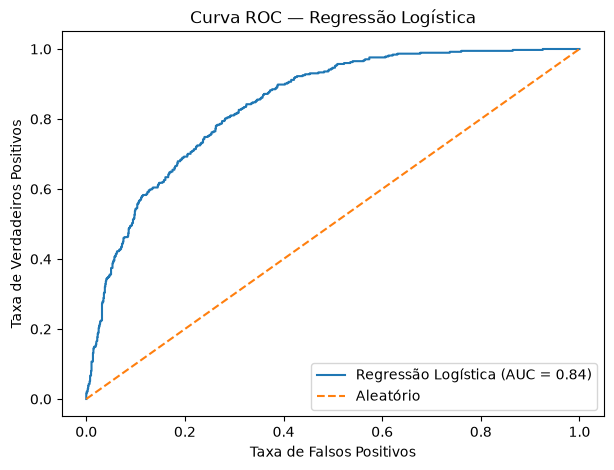

In [6]:
# Visualizar a curva ROC da Regressão Logística

fpr, tpr, _ = roc_curve(
    y_test,
    y_prob_logistico
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Regressão Logística (AUC = {roc_auc:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Aleatório"
)

plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curva ROC — Regressão Logística")
plt.legend()
plt.show()

## Conclusão da Avaliação

A Regressão Logística apresentou o melhor desempenho geral entre os modelos avaliados.

- Accuracy: 80,55%
- Recall para Churn: 56%
- F1-score para Churn: 0,60
- ROC-AUC: 0,84

O modelo apresenta boa capacidade de discriminação entre clientes com e sem churn. Entretanto, o recall de 56% indica que ainda existe espaço para melhorar a identificação dos clientes que efetivamente irão cancelar.

Para este projeto, a Regressão Logística foi selecionada como modelo principal por apresentar melhor equilíbrio geral de desempenho.

O modelo pode ser utilizado como apoio à estratégia de retenção de clientes, identificando grupos com maior probabilidade de cancelamento para ações preventivas.